<p class="mlx-kicker">Part III &middot; Training recipe &middot; Chapter 8</p>

# 8. Objective and loss: from labels to predicting the data itself

<dl class="mlx-meta"><div><dt>Level</dt><dd>Intermediate</dd></div><div><dt>Reading</dt><dd>about 25 min</dd></div><div><dt>Hands-on</dt><dd>about 6 min on a laptop CPU</dd></div><div><dt>You should know</dt><dd>Chapter 1, softmax and logarithms, what a gradient is</dd></div></dl>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daiyip/ml-explained/blob/main/chapters/08-objective/index.ipynb)

![The three generations of training objective. Each column highlights the one part that is new: minus the log probability of a human label, targets taken from the data itself, and objectives that denoise data or match pairs.](figures/objective-lineage.svg)

## What changed, and why it works

The architecture decides what a model *can* compute. The objective decides what it *will* learn: it is the single number that every gradient step tries to push down. Chapters 1 to 7 used one objective without comment, the cross-entropy of the next character. This chapter asks where that choice came from, what it replaced, and why predicting the next token turned out to be such a rich training signal. Each generation in Figure 8.1 changes where the target comes from.

<div class="mlx-why">
<section class="mlx-why__card mlx-why__card--1"><p class="mlx-why__n">1 &middot; Supervised</p><h3>Cross-entropy on human labels</h3><p><b>What changed.</b> Instead of the squared distance between the output and a one-hot target, classifiers minimize minus the log probability the softmax gives the correct label. AlexNet (2012) made this the default.</p><p><b>Why it works.</b> The gradient of cross-entropy on the logits is simply <i>p</i> minus the one-hot label, so a confident mistake gets the largest possible push. Squared error on probabilities multiplies that push by the softmax's slope, which is nearly zero when the model is confidently wrong, so the mistake is barely corrected.</p><p class="mlx-why__run">Our run, overconfident start: cross-entropy 0.964 test accuracy, squared error 0.894</p></section>
<section class="mlx-why__card mlx-why__card--2"><p class="mlx-why__n">2 &middot; Self-supervised</p><h3>The text is its own label</h3><p><b>What changed.</b> The targets are cut from the data itself: the next token (GPT), a hidden token (BERT), or a nearby word (word2vec). No human labelling is needed, so the training set can be the whole internet.</p><p><b>Why it works.</b> Next-token prediction turns every position of every sequence into a classification problem, so one sequence of 64 tokens gives 64 graded answers. To do well the model must model spelling, grammar, facts and style at once, because all of them help predict what comes next.</p><p class="mlx-why__run">Our runs: next token on every position 1.835, on 15% of positions 2.062</p></section>
<section class="mlx-why__card mlx-why__card--3"><p class="mlx-why__n">3 &middot; Generative and contrastive</p><h3>Denoise data, or match pairs</h3><p><b>What changed.</b> For data with no natural "next token", such as images, diffusion models learn to predict the noise added to a sample, and CLIP learns to tell which image goes with which caption among a batch of wrong ones.</p><p><b>Why it works.</b> Both turn an intractable goal (model the whole distribution, or understand both modalities) into a simple regression or classification that can be posed millions of times. Denoising at every noise level teaches the direction back toward the data from anywhere. Each wrong caption in a batch is a free negative example.</p><p class="mlx-why__run">Our runs: 80.2% of diffusion samples on the data curves (real data 89.9%); CLIP-style retrieval 60.2% with 255 negatives, 47.6% with 1</p></section>
</div>

Read left to right, the target moves from something a person writes down, to something cut out of the data, to something built from the data by corruption or pairing. Every step made labels cheaper, so models could train on more data. The steps below rebuild each objective and test it.

## Evolution path

| Year | Step | Level | What changed |
| --- | --- | --- | --- |
| 1980s-2000s | Squared error on network outputs | minor | regression loss reused for classification |
| 2012 | Softmax cross-entropy (AlexNet) | **major** | minus log probability of the human label; the default for classification ever since |
| 2013 | Skip-gram, word2vec | minor | predict nearby words; labels come from raw text |
| 2014 | Teacher forcing in seq2seq | minor | predict each output token given the true previous ones |
| 2013-2014 | VAE, GAN | minor | first deep generative objectives: a likelihood bound, and an adversarial game |
| 2018 | Next-token (GPT), masked LM (BERT) | **major** | self-supervised pretraining of Transformers on raw text |
| 2020 | Denoising diffusion (DDPM) | **major** | generate by learning to remove noise; a plain regression loss |
| 2021 | Contrastive image-text (CLIP) | **major** | match each image to its caption against all others in the batch |

## The lineage post-mortem: what drove each replacement?

| Replacement | Pressure that drove it | What it bought |
| --- | --- | --- |
| squared error to cross-entropy | confident mistakes were barely corrected | a gradient that is largest when the model is most wrong |
| human labels to self-supervision | labels are slow and expensive; raw text is free | training sets millions of times larger |
| masked LM to next-token | needing a model that can also write | one objective for both understanding and generation, with every position supervised |
| GAN to diffusion | unstable adversarial training, mode collapse | a stable regression loss and samples that cover the whole distribution |
| per-modality labels to contrastive pairs | images have no "next token"; labels have fixed classes | an open vocabulary learned from captions found on the web |

Read top to bottom, the pressure is almost always *where do the labels come from*. Each new objective found a way to manufacture targets from data that already existed. The model only improves as fast as the signal it is given, so the objectives that supply the most signal per example and the most examples per dollar won.

**Still open:** why next-token prediction gives representations good enough for reasoning, beyond "compression requires understanding"; whether a single objective can serve text, images and actions together (current models mostly stack several); and how much the objective, as opposed to the data and scale, explains the gap between GPT-style and BERT-style models.

## Diverged branches

The evolution path follows the line today's models inherited. At a few points the field split instead: two camps made different bets on the same problem, and sometimes both bets are still alive. Each tab below is one such fork, with the two branches, why they split, and how it has played out so far.

<div class="mlx-why mlx-forks" data-label="Forks in this lineage">
<section class="mlx-why__card mlx-why__card--1 mlx-fork"><p class="mlx-why__n">Fork 1 &middot; 2018-2022</p><h3>BERT vs. GPT: fill in the blanks, or predict the next token?</h3><div class="mlx-fork__sides"><div class="mlx-fork__side"><p class="mlx-fork__name">Masked LM (BERT) <span class="mlx-fork__state mlx-fork__state--alive">still used</span></p><p>Hide 15% of the tokens and predict them from both sides. An encoder that sees the whole input at once.</p><p class="mlx-fork__who">BERT, RoBERTa, ELECTRA, ModernBERT; search embeddings, classifiers</p></div><span class="mlx-fork__vs" aria-hidden="true">vs</span><div class="mlx-fork__side"><p class="mlx-fork__name">Next-token prediction (GPT) <span class="mlx-fork__state mlx-fork__state--main">mainline</span></p><p>Predict every token from the ones before it. A decoder that reads left to right and can generate.</p><p class="mlx-fork__who">GPT-1 to GPT-3, LLaMA, every chat model</p></div></div><p><b>Why they split.</b> In 2018 the goal was fine-tuning on benchmarks such as GLUE, where seeing both sides of a word helps, and BERT beat GPT-1 on most of them. Only GPT's objective could also write text. T5 took a third road: an encoder-decoder trained to fill in masked spans.</p><p><b>How it played out.</b> Next-token prediction won. Every token is a training target instead of 15%, and one model that generates can pose any task as text in and text out, which GPT-3 showed works without fine-tuning (chapter 12). Wang et al. (2022) compared the options at equal compute: causal decoders were best at zero-shot use straight after pretraining, encoder-decoders with masked objectives were best after multitask fine-tuning. Prompting replaced fine-tuning, and encoders survive where one vector per text is the goal, as in search. <strong>[established]</strong></p></section>
<section class="mlx-why__card mlx-why__card--2 mlx-fork"><p class="mlx-why__n">Fork 2 &middot; 2020-2023</p><h3>Images without labels: contrastive or masked?</h3><div class="mlx-fork__sides"><div class="mlx-fork__side"><p class="mlx-fork__name">Contrastive <span class="mlx-fork__state mlx-fork__state--alive">still used</span></p><p>Two augmented views of the same image should embed close together, other images far apart. CLIP (step 4) is the image-text version.</p><p class="mlx-fork__who">SimCLR, MoCo, CLIP, DINO</p></div><span class="mlx-fork__vs" aria-hidden="true">vs</span><div class="mlx-fork__side"><p class="mlx-fork__name">Masked reconstruction <span class="mlx-fork__state mlx-fork__state--alive">still used</span></p><p>Hide 75% of the patches and reconstruct the missing pixels: BERT's objective for images.</p><p class="mlx-fork__who">MAE, BEiT</p></div></div><p><b>Why they split.</b> Contrastive learning needs many negatives and hand-designed augmentations. Masked modeling needs neither and scales simply, but its features are weak until fine-tuned.</p><p><b>How it played out.</b> Neither replaced the other. MAE features shine after fine-tuning; contrastive and self-distillation features work frozen. DINOv2 combines self-distillation with a masked objective, and CLIP-style training supplies most vision encoders for multimodal LLMs. <strong>[likely]</strong></p></section>
<section class="mlx-why__card mlx-why__card--3 mlx-fork"><p class="mlx-why__n">Fork 3 &middot; 2014-2021</p><h3>Generating images: GANs or diffusion?</h3><div class="mlx-fork__sides"><div class="mlx-fork__side"><p class="mlx-fork__name">GANs <span class="mlx-fork__state mlx-fork__state--niche">niche</span></p><p>A generator and a discriminator play a game; one forward pass makes an image.</p><p class="mlx-fork__who">StyleGAN, BigGAN</p></div><span class="mlx-fork__vs" aria-hidden="true">vs</span><div class="mlx-fork__side"><p class="mlx-fork__name">Diffusion and flow matching <span class="mlx-fork__state mlx-fork__state--main">mainline</span></p><p>A plain regression loss: learn to remove noise, then generate by denoising step by step.</p><p class="mlx-fork__who">DDPM, Stable Diffusion, video models</p></div></div><p><b>Why they split.</b> GANs sample fast and sharp but train unstably and tend to drop modes of the data. Diffusion trains stably and covers the data, but needs many network passes per sample.</p><p><b>How it played out.</b> Dhariwal and Nichol (2021) showed diffusion beating the best GANs on ImageNet sample quality, and diffusion and its close relative flow matching took over image and video generation. The GAN's discriminator lives on in methods that distill diffusion models into few-step samplers. <strong>[established]</strong></p></section>
</div>

## Run it yourself

The steps share this setup. Steps 1, 3 and 4 use small synthetic datasets built in the notebook; step 2 trains three small Transformers on TinyShakespeare. Everything runs on a laptop CPU in about six minutes.

In [1]:
# Setup: works from a checkout of the repo and on Google Colab.
import pathlib, subprocess, sys

try:
    import mlexp
except ImportError:
    root = pathlib.Path.cwd().resolve().parents[1]
    if (root / "mlexp").is_dir():
        sys.path.insert(0, str(root))
    else:  # Colab: install the shared helpers from GitHub
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/daiyip/ml-explained"], check=True)
    import mlexp

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
mlexp.setup_style()
device_note = "GPU available" if torch.cuda.is_available() else "running on CPU"
print(f"torch {torch.__version__}, {device_note}")

torch 2.14.1+cu130, running on CPU


In [2]:
import math, time
from mlexp.transformer import TransformerLM

torch.set_num_threads(1)  # the models are tiny; raise this on your own machine for a little more speed
start_time = time.time()
tok, train_ids, val_ids = mlexp.load_char_corpus()

### Step 1 (major): cross-entropy on labels

#### The idea

A classifier outputs one score, a **logit**, per class. The **softmax** turns the logits into probabilities. Training needs a single number that says how wrong those probabilities are.

The obvious choice, borrowed from regression, is the **squared error** between the probability vector and the one-hot label. The choice that won is **cross-entropy**: minus the log of the probability given to the correct class. It is what you get by asking for the parameters that make the observed labels most likely (maximum likelihood), and it became the default with AlexNet (Krizhevsky et al., 2012). **[established]**

The difference shows up in the gradient. With cross-entropy, the gradient on the logits is the predicted probabilities minus the one-hot label. When the model gives the right class a probability near zero, that gradient is near its maximum. Squared error on the probabilities passes the error through the softmax's slope first, and the slope is nearly flat when the softmax is saturated. The model that is most wrong learns least.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: cross-entropy and its gradient</p><div class="mlx-eq">$$\mathcal{L}_{\mathrm{CE}} = -\log p_y, \qquad p = \mathrm{softmax}(z), \qquad \frac{\partial \mathcal{L}_{\mathrm{CE}}}{\partial z_k} = p_k - \mathbb{1}[k = y]$$</div><p class="mlx-eq__where">\(z\) are the logits and \(y\) the correct class. The gradient on the correct logit is \(p_y - 1\), which tends to \(-1\) as \(p_y \to 0\). For squared error \(\sum_k (p_k - \mathbb{1}[k=y])^2\), every term carries a factor of the softmax slope \(p_k(\mathbb{1}[k=j] - p_j)\), which tends to 0.</p></div>

We can see this directly by scanning how confident the model is in the right answer and asking each loss for its gradient.

at p_correct = 9.8e-05: cross-entropy gradient 1.118, squared-error gradient 2.8e-04


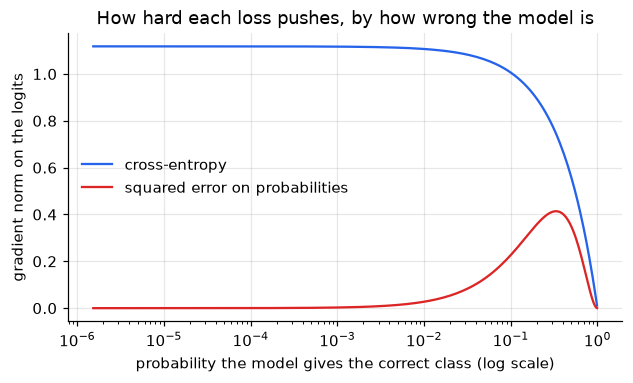

In [3]:
K = 5  # number of classes
p_correct, g_ce, g_mse = [], [], []
for zy in torch.linspace(-12, 6, 200):
    z = torch.zeros(K)
    z[0] = zy  # class 0 is the correct one; vary its logit
    z.requires_grad_(True)
    target = F.one_hot(torch.tensor(0), K).float()
    ce = F.cross_entropy(z[None], torch.tensor([0]))
    mse = (F.softmax(z, -1) - target).pow(2).sum()
    g_ce.append(torch.autograd.grad(ce, z)[0].norm().item())
    g_mse.append(torch.autograd.grad(mse, z)[0].norm().item())
    p_correct.append(F.softmax(z, -1)[0].item())

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.semilogx(p_correct, g_ce, label="cross-entropy")
ax.semilogx(p_correct, g_mse, label="squared error on probabilities")
ax.set(xlabel="probability the model gives the correct class (log scale)", ylabel="gradient norm on the logits",
       title="How hard each loss pushes, by how wrong the model is")
ax.legend(frameon=False);
i = int(np.argmin(np.abs(np.array(p_correct) - 1e-4)))
print(f"at p_correct = {p_correct[i]:.1e}: cross-entropy gradient {g_ce[i]:.3f}, squared-error gradient {g_mse[i]:.1e}")

At the far left, where the model is confidently wrong, cross-entropy pushes as hard as it ever does, while squared error has almost stopped. Squared error peaks in the middle and vanishes at both ends.

#### Experiment: a confidently wrong start

A gradient that vanishes for confident mistakes only matters if the model makes confident mistakes. Random initialization usually produces timid, near-uniform predictions, so we force the issue: we multiply the last layer's initial weights by 30, which makes the untrained network very sure of essentially random answers. This mimics what happens later in real training, when a model has become confident and then meets examples it gets badly wrong. We train the same 5-class spiral classifier with each loss, three seeds each.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">Both losses are minimized by the same perfect classifier. From an overconfident start, which loss reaches higher test accuracy, and what happens to the training points the model initially got confidently wrong?</p><details><summary>Show what happened</summary><p>Cross-entropy averages 0.964 test accuracy and leaves 0% of the training points stuck below 1% probability on their true class. Squared error averages 0.894, and 9.3% of its training points stay confidently wrong after 2,000 steps. One seed is hit much harder than the others.</p></details></div>

In [4]:
def spirals(n, k=5, seed=0):
    # k interleaved spiral arms in 2-D, one class per arm.
    g = torch.Generator().manual_seed(seed)
    t = torch.rand(n, generator=g) * 3 + 0.3
    c = torch.randint(k, (n,), generator=g)
    angle = t * 2.2 + c * 2 * math.pi / k
    x = torch.stack([t * angle.cos(), t * angle.sin()], 1) + 0.08 * torch.randn(n, 2, generator=g)
    return x, c


X_train, y_train = spirals(1000, seed=0)
X_test, y_test = spirals(3000, seed=1)


def train_classifier(loss_name, seed, init_scale=30.0, steps=2000):
    torch.manual_seed(seed)
    net = nn.Sequential(nn.Linear(2, 128), nn.ReLU(), nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, K))
    with torch.no_grad():
        net[-1].weight.mul_(init_scale)  # an overconfident start
    opt = torch.optim.SGD(net.parameters(), lr=0.05, momentum=0.9)
    for _ in range(steps):
        logits = net(X_train)
        if loss_name == "cross-entropy":
            loss = F.cross_entropy(logits, y_train)
        else:
            loss = (F.softmax(logits, -1) - F.one_hot(y_train, K).float()).pow(2).sum(-1).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    with torch.no_grad():
        p_true = F.softmax(net(X_train), -1)[torch.arange(len(y_train)), y_train]
        acc = (net(X_test).argmax(-1) == y_test).float().mean().item()
    return net, acc, (p_true < 0.01).float().mean().item(), p_true


results = {}
for loss_name in ["cross-entropy", "squared error"]:
    runs = [train_classifier(loss_name, seed) for seed in range(3)]
    results[loss_name] = runs
    accs = [r[1] for r in runs]
    stuck = [r[2] for r in runs]
    print(f"{loss_name:14s} test accuracy per seed {[round(a, 3) for a in accs]}  mean {np.mean(accs):.3f}   "
          f"confidently wrong (p_true < 1%) mean {np.mean(stuck):.1%}")

cross-entropy  test accuracy per seed [0.948, 0.951, 0.995]  mean 0.964   confidently wrong (p_true < 1%) mean 0.0%


squared error  test accuracy per seed [0.95, 0.778, 0.955]  mean 0.894   confidently wrong (p_true < 1%) mean 9.3%


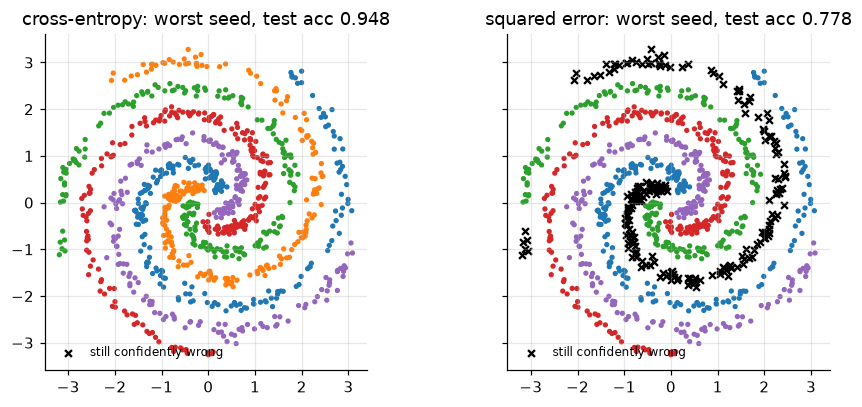

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharex=True, sharey=True)
for ax, loss_name in zip(axes, results):
    net, acc, stuck, p_true = min(results[loss_name], key=lambda r: r[1])  # each loss's worst seed
    bad = p_true < 0.01
    ax.scatter(*X_train[~bad].T, c=y_train[~bad], cmap="tab10", vmin=0, vmax=9, s=6)
    ax.scatter(*X_train[bad].T, c="black", marker="x", s=20, label="still confidently wrong")
    ax.set(title=f"{loss_name}: worst seed, test acc {acc:.3f}", aspect="equal")
    ax.legend(frameon=False, loc="lower left", fontsize=8)
fig.tight_layout();

#### Why it worked: a post-mortem

**Cross-entropy's gradient does not saturate.** Its gradient on the logits is the error itself, `p - y`, so a confident mistake receives a push of size about 1 no matter how wrong the model is. Squared error on softmax outputs multiplies the error by the softmax slope, which is close to zero exactly when the model is confidently wrong. The black crosses are points that squared error never managed to pull back. **[established]**

**The overconfident start costs both losses something.** Two of the three cross-entropy runs end near 0.95 instead of the 0.995 the third reaches, because a few regions were learned late. But cross-entropy leaves no training point stuck, while squared error's worst seed abandons whole stretches of two spiral arms. The mechanism is **[established]**; the size of the gap is specific to our toy and our seeds.

**This is the same story as the sigmoid in chapter 5.** A saturating function in the gradient path silences the signal. Cross-entropy's logarithm cancels the exponential inside the softmax, which is why the pair is used together almost everywhere. **[established]**

**Squared error is not useless.** From a gentle, timid initialization both losses reach similar accuracy on this problem, and later work found squared error on logits (not probabilities) competitive for some classification tasks (Hui and Belkin, 2021). **[likely]** The general lesson is that the loss must keep giving a strong gradient where the model is most wrong. Cross-entropy's other virtue is that it is a proper likelihood, which is what makes the next step possible: a language model is just a classifier over the vocabulary, trained with this exact loss at every position.

### Step 2 (major): predict the data itself

#### The idea

Cross-entropy needs a label. Labelled datasets are small: ImageNet has about a million images, each labelled by a person. Raw text is effectively unlimited, and it contains its own labels. Hide part of a sentence and the hidden part is the answer.

- **Skip-gram** (Mikolov et al., 2013) predicted the words around each word. It produced the word2vec embeddings, the first widely used self-supervised representation.
- **Teacher forcing**, an idea from recurrent networks (Williams and Zipser, 1989) that sequence-to-sequence models (Sutskever et al., 2014) made standard, trains a decoder to predict each output token given the *true* previous tokens rather than its own, possibly wrong, guesses, so all positions can be trained at once.
- **Next-token prediction** with a Transformer, **GPT** (Radford et al., 2018), applies this to raw text: every position predicts the token after it, with a causal mask so it cannot peek.
- **Masked language modelling**, **BERT** (Devlin et al., 2018), hides 15% of the tokens and predicts them from both sides.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equations: two self-supervised objectives</p><div class="mlx-eq">$$\mathcal{L}_{\text{next}} = -\frac{1}{T}\sum_{t=1}^{T} \log p_\theta(x_{t+1} \mid x_{\le t}), \qquad \mathcal{L}_{\text{MLM}} = -\frac{1}{|M|}\sum_{t \in M} \log p_\theta(x_t \mid x_{\setminus M})$$</div><p class="mlx-eq__where">\(M\) is the random set of masked positions, about 15% of \(T\), and \(x_{\setminus M}\) the sequence with those positions replaced by a mask token. The next-token loss scores all \(T\) positions; the masked loss only \(|M|\).</p></div>

Both are plain cross-entropy over the vocabulary. They differ in what the model may look at and in **how many positions give a gradient**. To separate those two effects we add a third, artificial objective: next-token prediction scored on only a random 15% of positions. It sees exactly what the full next-token model sees, but gets as few targets as BERT.

#### Minimal implementation

In [6]:
V = tok.vocab_size
MASK = V  # one extra token id for [MASK]


def objective_loss(model, x, y, kind, gen=None):
    # x: (B, T) input characters, y: (B, T) the same characters shifted by one.
    if kind == "next-token":  # every position predicts the next character
        logits, _ = model(x)
        return F.cross_entropy(logits.flatten(0, 1), y.flatten())
    if kind == "next-token, 15% of positions":  # same task, but only a random 15% of positions are scored
        logits, _ = model(x)
        keep = torch.rand(y.shape, generator=gen) < 0.15
        return F.cross_entropy(logits[keep], y[keep])
    if kind == "masked LM":  # hide 15% of the input, predict the hidden characters from both sides
        keep = torch.rand(x.shape, generator=gen) < 0.15
        logits, _ = model(x.masked_fill(keep, MASK))
        return F.cross_entropy(logits[keep], x[keep])


def make_model(kind, seed=0):
    torch.manual_seed(seed)
    return TransformerLM(V + 1, dim=96, n_layers=3, n_heads=4, causal=(kind != "masked LM"))


@torch.no_grad()
def eval_loss(model, kind, iters=20):
    gen = torch.Generator().manual_seed(1234)
    model.eval()
    losses = [objective_loss(model, *mlexp.get_batch(val_ids, 32, 64, gen), kind, gen).item() for _ in range(iters)]
    model.train()
    return sum(losses) / len(losses)


def train_objective(kind, steps=500, lr=3e-3, seed=0):
    model = make_model(kind, seed)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=0.1)
    gen = torch.Generator().manual_seed(seed)
    warmup = steps // 10
    history = {"step": [], "val": []}
    for step in range(steps + 1):
        if step % 100 == 0:
            history["step"].append(step)
            history["val"].append(eval_loss(model, "masked LM" if kind == "masked LM" else "next-token"))
        if step == steps:
            break
        progress = max(0.0, (step - warmup) / (steps - warmup))
        for group in opt.param_groups:  # warmup, then cosine decay (as in mlexp.train_lm)
            group["lr"] = lr * min((step + 1) / warmup, 0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * progress)))
        x, y = mlexp.get_batch(train_ids, 32, 64, gen)
        loss = objective_loss(model, x, y, kind, gen)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
    return model, history

#### Experiment: three objectives at equal compute

Each model has the same size and sees the same 500 batches of 32 windows of 64 characters, so the cost of each forward and backward pass is the same. Only the objective differs. Each run takes about a minute.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">The full next-token model and the 15% next-token model see exactly the same text and do the same computation. How much worse will the 15% model be at predicting the next character?</p><details><summary>Show what happened</summary><p>Much worse: 2.062 against 1.835 nats per character, a gap larger than any architectural change in chapter 5. Throwing away 85% of the targets costs far more than the compute it does not save.</p></details></div>

next-token                     val loss on the next character: 1.835  (61s)


next-token, 15% of positions   val loss on the next character: 2.062  (59s)


masked LM                      val loss on the masked characters: 1.710  (61s)


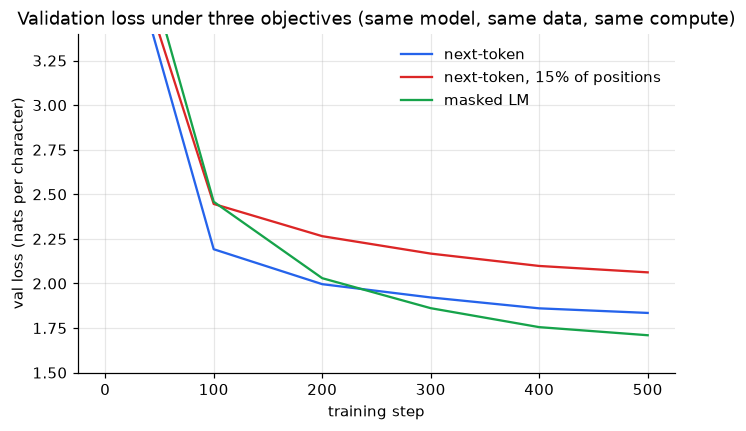

In [7]:
lm_models, lm_histories = {}, {}
for kind in ["next-token", "next-token, 15% of positions", "masked LM"]:
    t0 = time.time()
    lm_models[kind], lm_histories[kind] = train_objective(kind)
    scored = "masked characters" if kind == "masked LM" else "next character"
    print(f"{kind:30s} val loss on the {scored}: {lm_histories[kind]['val'][-1]:.3f}  ({time.time() - t0:.0f}s)")

ax = mlexp.plot_histories(lm_histories, "Validation loss under three objectives (same model, same data, same compute)")
ax.set_ylim(1.5, 3.4);

The masked model's curve measures a different, easier task: predicting a hidden character with the characters on *both* sides visible. Its loss is not comparable with the other two, and a masked model cannot generate text left to right at all. The two next-token curves are directly comparable, and the gap between them is entirely due to how many positions give a gradient.

#### Experiment: what did the representations learn?

A loss value only says how well a model does its own task. To compare the *representations*, we freeze each model and fit a **linear probe**: a single logistic-regression layer on the final hidden state of each letter, trained to predict a simple label we derive from the text. If a linear layer can read the label off the hidden state, the model has made that information explicit. We use two labels:

- **"4th letter or later in its word"**: requires counting back to the start of the word.
- **"last letter of its word"**: requires knowing what comes next.

We also probe a randomly initialized model, which shows how much a probe can extract from the character identity and the architecture alone.

4th letter or later    majority-class baseline 0.673
last letter of word    majority-class baseline 0.750
random init                    4th letter or later: 0.699   last letter of word: 0.775
next-token                     4th letter or later: 0.935   last letter of word: 0.912
next-token, 15% of positions   4th letter or later: 0.906   last letter of word: 0.877
masked LM                      4th letter or later: 0.913   last letter of word: 0.925


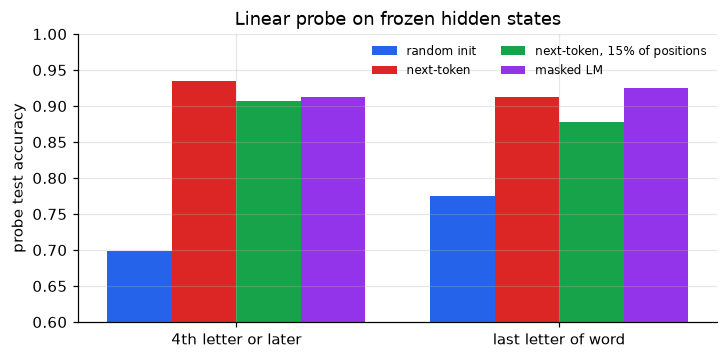

In [8]:
n_win = 600
probe_ids = val_ids[: n_win * 64]
text = tok.decode(probe_ids)
is_letter = torch.tensor([c.isalpha() for c in text])
letter_index, last_letter = [], []
k = 0
for i, c in enumerate(text):
    k = k + 1 if (c.isalpha() and i > 0 and text[i - 1].isalpha()) else 0
    letter_index.append(c.isalpha() and k >= 3)
    last_letter.append(c.isalpha() and (i + 1 == len(text) or not text[i + 1].isalpha()))
labels = {"4th letter or later": torch.tensor(letter_index), "last letter of word": torch.tensor(last_letter)}
use = is_letter & (torch.arange(len(text)) % 64 >= 16)  # letters with at least 16 characters of context


@torch.no_grad()
def hidden_states(model):
    h = model.embed(probe_ids.view(n_win, 64))
    for block in model.blocks:
        h = block(h)
    return model.norm(h).reshape(len(probe_ids), -1)


def linear_probe(features, label):
    x, y = features[use], label[use].float()
    n = int(0.7 * len(y))  # first 70% to fit, last 30% to test
    x = (x - x[:n].mean(0)) / (x[:n].std(0) + 1e-5)
    clf = nn.Linear(x.shape[1], 1)
    opt = torch.optim.LBFGS(clf.parameters(), max_iter=200, line_search_fn="strong_wolfe")

    def closure():
        opt.zero_grad()
        loss = F.binary_cross_entropy_with_logits(clf(x[:n]).squeeze(-1), y[:n]) + 1e-4 * clf.weight.pow(2).sum()
        loss.backward()
        return loss

    opt.step(closure)
    with torch.no_grad():
        return ((clf(x[n:]).squeeze(-1) > 0).float() == y[n:]).float().mean().item()


probe_models = {"random init": make_model("next-token", seed=1), **lm_models}
probe_acc = {name: {lab: linear_probe(hidden_states(m), y) for lab, y in labels.items()} for name, m in probe_models.items()}
for lab, y in labels.items():
    base = y[use].float()[int(0.7 * use.sum()):].mean().item()
    print(f"{lab:22s} majority-class baseline {max(base, 1 - base):.3f}")
for name, accs in probe_acc.items():
    print(f"{name:30s} " + "   ".join(f"{lab}: {a:.3f}" for lab, a in accs.items()))

fig, ax = plt.subplots(figsize=(7.5, 3.4))
width = 0.2
for j, (name, accs) in enumerate(probe_acc.items()):
    ax.bar(np.arange(2) + (j - 1.5) * width, list(accs.values()), width, label=name)
ax.set(xticks=range(2), xticklabels=list(labels), ylabel="probe test accuracy", ylim=(0.6, 1.0),
       title="Linear probe on frozen hidden states")
ax.legend(frameon=False, fontsize=8, ncol=2);

#### Why it worked: a post-mortem

**Dense targets are most of the advantage.** With the input, the model and the compute held fixed, scoring every position instead of 15% of them lowered the next-character loss from 2.062 to 1.835. Each position is a separate, graded classification problem, so a 64-character window yields 64 lessons, not about 10. ELECTRA (Clark et al., 2020) made the same argument against BERT: it learns from only 15% of tokens, and replacing masking with a task defined on every token trained much faster. **[established]**

**The next token is a demanding target.** To predict the next character well, a model must track the position within a word, which word is likely, the grammar of the sentence and, at larger scale, facts and the intent of the writer. Every one of those helps the loss, so gradient descent builds all of them. In our probe, the next-token model encodes "4th letter or later" with 0.935 accuracy against 0.699 for a random model, and "last letter of word", which it can only anticipate, with 0.912. The 15% model trails it on both (0.906 and 0.877): fewer targets also meant less structure in the representations. This "prediction requires understanding" view is the most common explanation of why next-token pretraining transfers so well. **[likely]**

**Masked LM is not simply worse.** Seeing both sides makes BERT-style representations strong for understanding tasks, and at the 2018-2019 scale BERT beat GPT on classification benchmarks. **[established]** Our probe agrees in miniature: the masked model is best on "last letter of word" (0.925), which it can read off directly because it sees the following character, while the next-token model is best on the backward-looking "4th letter or later" (0.935 against 0.913). One caveat: our masked model is trained only on masked positions but probed on unmasked text. BERT replaces 10% of the selected tokens with random ones and leaves 10% unchanged, partly so that unmasked positions also learn useful states.

**Why next-token won anyway.** It is a generator as well as an encoder, every token supervises, and its loss keeps falling smoothly with scale (chapter 12). **[likely]** The claim that next-token prediction alone suffices for general intelligence is **[speculative]**.

### Step 3 (major): denoising diffusion

#### The problem before

Images have no natural "next token". The first deep generative objectives took two other routes. The **variational autoencoder** (Kingma and Welling, 2013) maximizes a lower bound on the likelihood, and its samples come out blurry. The **generative adversarial network** (Goodfellow et al., 2014) trains a generator to fool a discriminator. GANs produced sharp images, but the objective is a two-player game with no single loss going down: training is unstable and the generator often covers only part of the data, called **mode collapse**. **[established]**

#### The idea

**Denoising diffusion** (Sohl-Dickstein et al., 2015; Ho et al., 2020) turns generation into many easy regression problems. Take a data point, add Gaussian noise of a random strength `t`, and train a network to predict the noise that was added. To generate, start from pure noise and repeatedly subtract a little of the predicted noise. Every training step is an ordinary squared-error regression with a fixed target, so training is as stable as fitting a classifier.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: the denoising objective (DDPM)</p><div class="mlx-eq">$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon, \qquad \mathcal{L} = \mathbb{E}_{x_0,\,t,\,\varepsilon}\,\big\|\varepsilon - \varepsilon_\theta(x_t, t)\big\|^2$$</div><p class="mlx-eq__where">\(x_0\) is a data point, \(\varepsilon\) standard Gaussian noise and \(\bar\alpha_t\) falls from 1 (clean) to almost 0 (pure noise) as \(t\) goes from 0 to \(T\). The network \(\varepsilon_\theta\) sees the noisy point and the noise level.</p></div>

#### Minimal implementation

Our "images" are points in 2-D drawn from two interleaved half circles, the classic two-moons dataset. The denoiser is a small MLP that also receives the noise level as sine and cosine features. Training takes about 25 seconds.

In [9]:
def two_moons(n, g):
    t = torch.rand(n, generator=g) * math.pi
    upper = torch.rand(n, generator=g) < 0.5
    x = torch.where(upper, t.cos(), 1 - t.cos())
    y = torch.where(upper, t.sin(), 0.5 - t.sin())
    pts = torch.stack([x, y], 1) + 0.05 * torch.randn(n, 2, generator=g)
    return (pts - torch.tensor([0.5, 0.25])) / 0.8  # roughly centred, unit scale


T = 100
# Cosine schedule (Nichol and Dhariwal, 2021): the share of signal left, alpha_bar, falls from 1 to 0 along a cosine.
f = lambda t: math.cos((t / T + 0.008) / 1.008 * math.pi / 2) ** 2
alpha_bar = torch.tensor([f(t + 1) / f(0) for t in range(T)])
betas = (1 - alpha_bar / torch.cat([torch.ones(1), alpha_bar[:-1]])).clamp(max=0.999)  # noise added at each step
alphas = 1 - betas


class Denoiser(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2 + 16, hidden), nn.SiLU(), nn.Linear(hidden, hidden), nn.SiLU(),
                                 nn.Linear(hidden, hidden), nn.SiLU(), nn.Linear(hidden, 2))

    def forward(self, x, t):
        freqs = torch.exp(-math.log(1000) * torch.arange(8) / 8)
        angles = t[:, None].float() * freqs
        return self.net(torch.cat([x, angles.sin(), angles.cos()], 1))  # predicted noise


torch.manual_seed(0)
denoiser = Denoiser()
steps = 10000
opt = torch.optim.Adam(denoiser.parameters(), lr=2e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, steps)
gen = torch.Generator().manual_seed(0)
for step in range(steps):
    x0 = two_moons(256, gen)
    t = torch.randint(T, (256,), generator=gen)
    eps = torch.randn(256, 2, generator=gen)
    xt = alpha_bar[t].sqrt()[:, None] * x0 + (1 - alpha_bar[t]).sqrt()[:, None] * eps
    loss = F.mse_loss(denoiser(xt, t), eps)  # the whole objective
    opt.zero_grad()
    loss.backward()
    opt.step()
    sched.step()


@torch.no_grad()
def sample(n, seed=1):
    g = torch.Generator().manual_seed(seed)
    x = torch.randn(n, 2, generator=g)  # start from pure noise
    snapshots = {T: x.clone()}
    for t in reversed(range(T)):
        eps_hat = denoiser(x, torch.full((n,), t))
        x = (x - betas[t] / (1 - alpha_bar[t]).sqrt() * eps_hat) / alphas[t].sqrt()  # remove a little noise
        if t > 0:
            x = x + betas[t].sqrt() * torch.randn(n, 2, generator=g)
        snapshots[t] = x.clone()
    return x, snapshots


samples, snapshots = sample(2000)

#### Experiment: does it learn the shape?

We measure how many generated points land within 0.1 of the two noiseless half circles, and compare with real data and with the best single Gaussian (same mean and covariance as the data), which is what a model would produce if it only learned the overall spread.

real data          share within 0.1 of the true curves: 89.9%
single Gaussian    share within 0.1 of the true curves: 16.6%
diffusion samples  share within 0.1 of the true curves: 80.2%


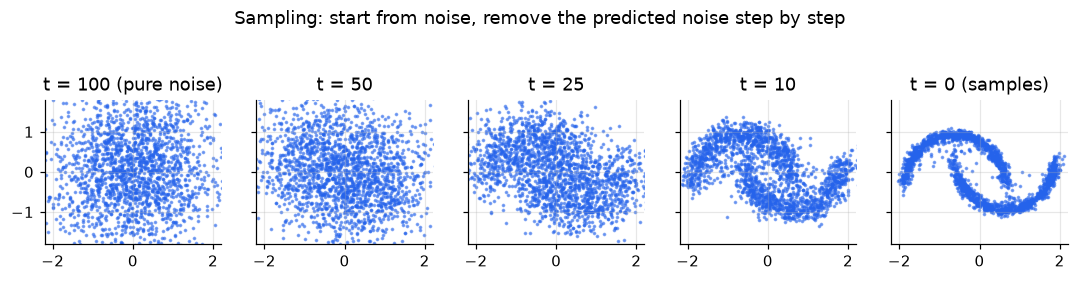

In [10]:
s = torch.linspace(0, math.pi, 2000)
curve = torch.cat([torch.stack([s.cos(), s.sin()], 1), torch.stack([1 - s.cos(), 0.5 - s.sin()], 1)])
curve = (curve - torch.tensor([0.5, 0.25])) / 0.8
on_curve = lambda pts: (torch.cdist(pts, curve).min(1).values < 0.1).float().mean().item()

real = two_moons(2000, torch.Generator().manual_seed(5))
gauss = torch.distributions.MultivariateNormal(real.mean(0), torch.cov(real.T)).sample((2000,))
for name, pts in [("real data", real), ("single Gaussian", gauss), ("diffusion samples", samples)]:
    print(f"{name:18s} share within 0.1 of the true curves: {on_curve(pts):.1%}")

fig, axes = plt.subplots(1, 5, figsize=(12, 2.7), sharex=True, sharey=True)
for ax, t in zip(axes, [100, 50, 25, 10, 0]):
    ax.scatter(*snapshots[t].T, s=2, alpha=0.5)
    ax.set(title=f"t = {t}" + (" (pure noise)" if t == T else " (samples)" if t == 0 else ""),
           xlim=(-2.2, 2.2), ylim=(-1.8, 1.8), aspect="equal")
fig.suptitle("Sampling: start from noise, remove the predicted noise step by step", y=1.04);

#### Why it worked: a post-mortem

Our samples land within 0.1 of the true curves 80.2% of the time, against 89.9% for real data and 16.6% for the best single Gaussian. The model has learned the shape, not just the spread, with some stray points between the arms that more training reduces.

**A fixed regression target is easy to optimize.** Each training step asks a simple question with a definite answer: which noise was added? There is no opponent whose moves change the target, unlike a GAN, so the loss falls steadily and every training point contributes. **[established]**

**Predicting noise at every level teaches a direction field.** At high noise the network learns where the data is on average; at low noise it learns fine detail. Predicting the noise turns out to be equivalent, up to scaling, to estimating the gradient of the log density of the noised data, the **score** (Song and Ermon, 2019), so sampling follows that field back toward the data. **[established]** The snapshots above show exactly this: the cloud first contracts to the rough shape, then sharpens onto the curves.

**Why it beat GANs on coverage.** The loss is an average over all data points, so a model that ignored one moon would pay for it on every training example from that moon; a GAN's generator pays nothing for a mode it never produces as long as the discriminator is fooled. **[likely]** The price is speed: sampling took 100 network calls here, and much later work (distillation, flow matching) aims to reduce that.

### Step 4 (minor): contrastive matching, CLIP

#### The idea

CLIP (Radford et al., 2021) trained an image encoder and a text encoder on 400 million image-caption pairs from the web. Neither encoder predicts the other's content. Instead, for a batch of `N` pairs, both encoders map their input to a vector, and the model is scored on picking the right caption for each image among all `N` captions in the batch, and the right image for each caption. That is a cross-entropy over the batch, called **InfoNCE** (van den Oord et al., 2018). Every other pair in the batch is a free negative example.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: the symmetric InfoNCE loss</p><div class="mlx-eq">$$\mathcal{L} = -\frac{1}{2N}\sum_{i=1}^{N}\left[\log \frac{e^{s_{ii}/\tau}}{\sum_{j} e^{s_{ij}/\tau}} + \log \frac{e^{s_{ii}/\tau}}{\sum_{j} e^{s_{ji}/\tau}}\right], \qquad s_{ij} = \frac{f(a_i)\cdot g(b_j)}{\|f(a_i)\|\,\|g(b_j)\|}$$</div><p class="mlx-eq__where">\(f\) and \(g\) are the two encoders, \(s_{ij}\) the cosine similarity between item \(i\) of one view and item \(j\) of the other, and \(\tau\) a temperature. The matching pairs lie on the diagonal.</p></div>

Our toy has no images: a hidden 8-dimensional "meaning" `z` is turned into two different noisy views by two different random nonlinear maps, a 48-dimensional "image" and a 24-dimensional "caption". The encoders must discover the shared meaning from pairing alone. To isolate the role of negatives we keep the batch at 256 pairs and limit how many of the other 255 each row is compared against.

In [11]:
D_LATENT = 8
gA, gB = torch.Generator().manual_seed(10), torch.Generator().manual_seed(20)
map_a = [torch.randn(D_LATENT, 32, generator=gA) / math.sqrt(D_LATENT), torch.randn(32, 48, generator=gA) / math.sqrt(32)]
map_b = [torch.randn(D_LATENT, 32, generator=gB) / math.sqrt(D_LATENT), torch.randn(32, 24, generator=gB) / math.sqrt(32)]


def paired_views(n, g):
    z = torch.randn(n, D_LATENT, generator=g)  # the shared meaning
    a = torch.tanh(z @ map_a[0]) @ map_a[1] + 0.3 * torch.randn(n, 48, generator=g)  # "image"
    b = torch.tanh(z @ map_b[0]) @ map_b[1] + 0.3 * torch.randn(n, 24, generator=g)  # "caption"
    return a, b


encoder = lambda d_in: nn.Sequential(nn.Linear(d_in, 128), nn.ReLU(), nn.Linear(128, 32))


def train_clip(n_neg, batch=256, steps=1000, tau=0.1, seed=0):
    torch.manual_seed(seed)
    f, g_enc = encoder(48), encoder(24)
    opt = torch.optim.Adam([*f.parameters(), *g_enc.parameters()], lr=1e-3)
    gen = torch.Generator().manual_seed(seed)
    labels = torch.arange(batch)
    for _ in range(steps):
        a, b = paired_views(batch, gen)
        sim = F.normalize(f(a), dim=-1) @ F.normalize(g_enc(b), dim=-1).T / tau  # (batch, batch)
        # keep the matching pair and n_neg random other pairs in each row; hide the rest
        r = torch.rand(batch, batch, generator=gen).fill_diagonal_(-1)
        kept = r.argsort(1)[:, : n_neg + 1]
        hide = torch.full((batch, batch), float("-inf")).scatter_(1, kept, 0.0)
        loss = (F.cross_entropy(sim + hide, labels) + F.cross_entropy(sim.T + hide, labels)) / 2
        opt.zero_grad()
        loss.backward()
        opt.step()
    return f, g_enc


@torch.no_grad()
def retrieval_accuracy(f, g_enc, n=1000):
    a, b = paired_views(n, torch.Generator().manual_seed(99))
    sim = F.normalize(f(a), dim=-1) @ F.normalize(g_enc(b), dim=-1).T
    return (sim.argmax(1) == torch.arange(n)).float().mean().item(), sim

#### Experiment: how much do negatives matter?

We train three pairs of encoders that see the same 256 pairs per step for 1,000 steps, comparing each "image" against 1, 15 or 255 wrong "captions". We then ask each to find the right caption for 1,000 new images among 1,000 candidates (chance is 0.1%).

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">All three runs see exactly the same data. Does comparing against more wrong captions help retrieval, and by how much?</p><details><summary>Show what happened</summary><p>It helps steadily: 47.6% with 1 negative, 55.5% with 15 and 60.2% with 255. More negatives make the task harder during training, so the encoders must separate items more finely.</p></details></div>

  1 negatives per pair: top-1 retrieval among 1,000 = 47.6%


 15 negatives per pair: top-1 retrieval among 1,000 = 55.5%


255 negatives per pair: top-1 retrieval among 1,000 = 60.2%
untrained encoders:            top-1 retrieval among 1,000 = 0.1%


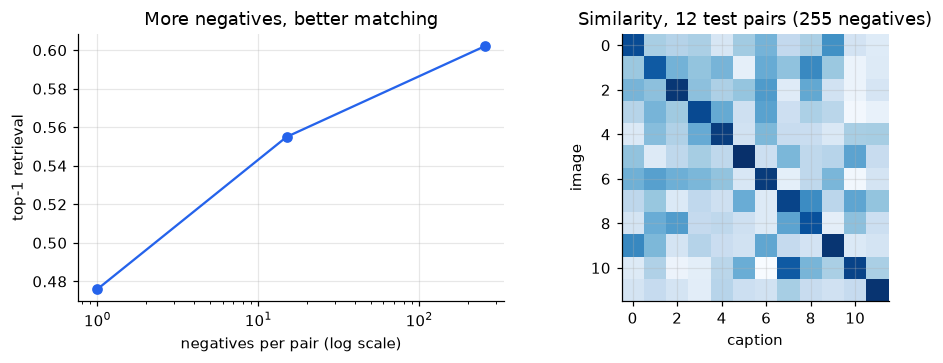

In [12]:
clip_acc = {}
for n_neg in [1, 15, 255]:
    f, g_enc = train_clip(n_neg)
    clip_acc[n_neg], sim = retrieval_accuracy(f, g_enc)
    print(f"{n_neg:3d} negatives per pair: top-1 retrieval among 1,000 = {clip_acc[n_neg]:.1%}")
torch.manual_seed(0)
print(f"untrained encoders:            top-1 retrieval among 1,000 = {retrieval_accuracy(encoder(48), encoder(24))[0]:.1%}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4))
ax1.plot(list(clip_acc), list(clip_acc.values()), marker="o")
ax1.set(xscale="log", xlabel="negatives per pair (log scale)", ylabel="top-1 retrieval", title="More negatives, better matching")
ax2.imshow(sim[:12, :12], cmap="Blues")
ax2.set(title="Similarity, 12 test pairs (255 negatives)", xlabel="caption", ylabel="image",
        xticks=range(0, 12, 2), yticks=range(0, 12, 2))
fig.tight_layout();

#### Why it worked: a post-mortem

**The batch supplies the labels.** No one wrote a class name; the only supervision is "these two go together". Each extra pair in the batch adds a negative at almost no cost, and harder discrimination forces finer features. This is why CLIP used batches of 32,768. **[established]** Note that InfoNCE is, once again, a softmax cross-entropy: the "classes" are the other items in the batch.

**Why it mattered.** Because captions are free text, the learned space is not tied to a fixed list of classes: a CLIP model classifies a new image by comparing it with the embedding of any sentence, "zero-shot". **[established]** CLIP's text encoder was later reused to guide diffusion models (DALL-E 2, Stable Diffusion), which is where the two branches of Figure 8.1 meet.

**Where it breaks.** With small batches or easy negatives the encoders can satisfy the loss with crude features, and captions scraped from the web are noisy, so CLIP is weak at counting and at word order. **[likely]**

## Across three seeds

The numbers on this page come from one run, seed 0. We reran the whole notebook twice more with every random seed shifted by 1 and by 2, which changes the initial weights, the batches and the evaluation samples (the `Seed runs` workflow in the repository does this for any chapter). A gap between two runs means something only when it is clearly larger than their spread.

| Run | This page (seed 0) | Mean ± sd, 3 seeds | Seeds 0 / 1 / 2 |
| --- | --- | --- | --- |
| cross-entropy, mean test accuracy | 0.964 | 0.983 ± 0.016 | 0.964 / 0.992 / 0.993 |
| squared error, mean test accuracy | 0.894 | 0.884 ± 0.032 | 0.894 / 0.849 / 0.910 |
| squared error, % confidently wrong | 9.3% | 10.3% ± 3.6% | 9.3% / 14.3% / 7.4% |
| next-token, val loss per character | 1.835 | 1.841 ± 0.008 | 1.835 / 1.850 / 1.839 |
| next-token on 15% of positions | 2.062 | 2.067 ± 0.004 | 2.062 / 2.069 / 2.069 |
| masked LM, loss on masked characters | 1.710 | 1.708 ± 0.013 | 1.710 / 1.694 / 1.719 |
| diffusion samples near the true curves | 80.2% | 82.1% ± 1.6% | 80.2% / 83.3% / 82.7% |
| contrastive, 1 negative | 47.6% | 52.0% ± 5.8% | 47.6% / 49.7% / 58.6% |
| contrastive, 15 negatives | 55.5% | 58.9% ± 4.8% | 55.5% / 56.9% / 64.4% |
| contrastive, 255 negatives | 60.2% | 63.3% ± 4.9% | 60.2% / 60.8% / 69.0% |

Every comparison held in all three seeds. The contrastive scores move by several points from seed to seed, but more negatives helped in each one.

## Recap

<div class="mlx-box mlx-box--objectives"><p class="mlx-box__label">Recap</p><p>You should now be able to:</p><ol><li>Derive the cross-entropy gradient on the logits and explain why squared error on probabilities stalls on confident mistakes.</li><li>Write next-token and masked-LM losses and explain why scoring every position gives a richer signal.</li><li>Implement a denoising diffusion objective and a sampler for 2-D data.</li><li>Implement the symmetric InfoNCE loss and explain the role of negatives.</li></ol></div>

<div class="mlx-box mlx-box--check"><p class="mlx-box__label">Check your understanding</p><details><summary>What is the gradient of the cross-entropy loss with respect to the logits, and why does it not vanish when the model is confidently wrong?</summary><p>It is p minus the one-hot label. When the correct class has probability near 0, the entry for that class is close to -1, the largest it can be. The logarithm in the loss cancels the exponential in the softmax, so no saturating slope is left in the path.</p></details><details><summary>A next-token model and a model scored on 15% of positions see the same text and do the same computation. Why does the first learn faster?</summary><p>Every scored position contributes its own gradient, so the full model receives about 6.7 times as many supervised predictions per batch. The compute of the forward and backward pass is the same, so the extra signal is nearly free.</p></details><details><summary>Why is the diffusion objective more stable to train than a GAN?</summary><p>Its target, the added noise, is fixed and known, so training is an ordinary regression. A GAN's generator chases a discriminator that keeps changing, a two-player game with no single loss that must go down.</p></details><details><summary>In CLIP, where do the negative examples come from, and why does the batch size matter?</summary><p>They are the other images and captions in the same batch. A larger batch gives more, and harder, negatives per pair, so the encoders must learn finer distinctions.</p></details></div>

## Further reading

- Krizhevsky, Sutskever and Hinton, 2012, [ImageNet Classification with Deep Convolutional Neural Networks](https://papers.nips.cc/paper/2012/hash/c399862d3b9d6b76c8436e924a68c45b-Abstract.html): AlexNet, softmax cross-entropy at scale.
- Mikolov et al., 2013, [Distributed Representations of Words and Phrases and their Compositionality](https://arxiv.org/abs/1310.4546): skip-gram with negative sampling.
- Radford et al., 2018, [Improving Language Understanding by Generative Pre-Training](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf): GPT.
- Devlin et al., 2018, [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](https://arxiv.org/abs/1810.04805).
- Clark et al., 2020, [ELECTRA: Pre-training Text Encoders as Discriminators Rather Than Generators](https://arxiv.org/abs/2003.10555): why masking wastes signal.
- Goodfellow et al., 2014, [Generative Adversarial Networks](https://arxiv.org/abs/1406.2661).
- Ho, Jain and Abbeel, 2020, [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239).
- Radford et al., 2021, [Learning Transferable Visual Models From Natural Language Supervision](https://arxiv.org/abs/2103.00020): CLIP.
- Raffel et al., 2019, [Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer](https://arxiv.org/abs/1910.10683): T5.
- Wang et al., 2022, [What Language Model Architecture and Pretraining Objective Work Best for Zero-Shot Generalization?](https://arxiv.org/abs/2204.05832)
- Warner et al., 2024, [Smarter, Better, Faster, Longer: A Modern Bidirectional Encoder for Fast, Memory Efficient, and Long Context Finetuning and Inference](https://arxiv.org/abs/2412.13663): ModernBERT.
- Chen et al., 2020, [A Simple Framework for Contrastive Learning of Visual Representations](https://arxiv.org/abs/2002.05709): SimCLR.
- He et al., 2021, [Masked Autoencoders Are Scalable Vision Learners](https://arxiv.org/abs/2111.06377).
- Oquab et al., 2023, [DINOv2: Learning Robust Visual Features without Supervision](https://arxiv.org/abs/2304.07193).
- Dhariwal and Nichol, 2021, [Diffusion Models Beat GANs on Image Synthesis](https://arxiv.org/abs/2105.05233).
- Lipman et al., 2022, [Flow Matching for Generative Modeling](https://arxiv.org/abs/2210.02747).